In [72]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [73]:
class BatsmanState(TypedDict):
    runs: int 
    balls : int 
    fours : int 
    sixes : int

    sr : float 
    brp : float
    boundary_percent : float
    summary : str 

In [74]:
def calculate_sr(state : BatsmanState):
    sr = (state['runs']/state['balls'])*100

   

    return {'sr': sr}

In [75]:
def calculate_bpb(state : BatsmanState):

    brp  = (state['balls']/(state['fours']+state['sixes']))

    

    return {'brp': brp}

In [76]:
def calculate_boundary_percent(state : BatsmanState):
    boundary_percent = (((state['fours']*4)+(state['sixes']*6))/state['runs'])*100

   

    return{'boundary_percent': boundary_percent}

In [77]:
def summary(state : BatsmanState):
   summary =f"""
strike rate  -{state['sr']}\n
Ball per boundary -{state['brp']}\n
Boundary percent -{state['boundary_percent']}
"""
    
   

   return{'summary': summary}

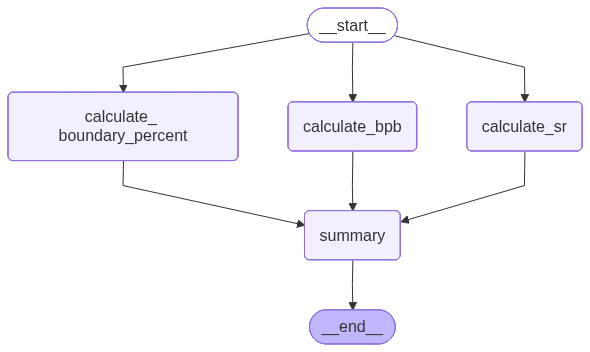

In [78]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr' , calculate_sr )
graph.add_node('calculate_bpb' ,calculate_bpb )
graph.add_node('calculate_ boundary_percent' ,calculate_boundary_percent)
graph.add_node('summary' , summary)


# edges 

graph.add_edge(START ,'calculate_sr' )
graph.add_edge(START ,'calculate_bpb' )
graph.add_edge(START ,'calculate_ boundary_percent' )


graph.add_edge('calculate_sr','summary' )
graph.add_edge('calculate_bpb','summary' )
graph.add_edge('calculate_ boundary_percent','summary')

graph.add_edge('summary', END)



graph.compile()

In [79]:
workflow = graph.compile()


In [80]:
initial_state = {
    'runs' : 100 ,
    'balls':50,
    'fours' : 6 ,
    'sixes' : 4 

}
workflow.invoke(initial_state)



{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'brp': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nstrike rate  -200.0\n\nBall per boundary -5.0\n\nBoundary percent -48.0\n'}